In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [8]:
import numpy as np

# Generate synthetic data to mimic fraudTrain.csv structure
n_samples = 100000 # Simulating a reasonably sized dataset
np.random.seed(42)

data = {
    'TransactionID': np.arange(n_samples),
    'Step': np.random.randint(1, 744, n_samples), # simulate time steps/hours
    'Amount': np.random.exponential(scale=100, size=n_samples), # simulate transaction amounts
    'OldBalanceDest': np.random.uniform(0, 100000, n_samples),
    'NewBalanceDest': np.random.uniform(0, 100000, n_samples),
    'is_fraud': np.random.choice([0, 1], size=n_samples, p=[0.99, 0.01]) # 1% fraudulent transactions
}

# Ensure fraudulent transactions have slightly different characteristics (e.g., higher amounts)
fraud_indices = (data['is_fraud'] == 1)
num_fraud = fraud_indices.sum()
data['Amount'][fraud_indices] = np.random.exponential(scale=500, size=num_fraud)
data['OldBalanceDest'][fraud_indices] = np.random.uniform(1000, 200000, num_fraud)
data['NewBalanceDest'][fraud_indices] = np.random.uniform(1000, 200000, num_fraud)

df = pd.DataFrame(data)

# Add a 'Class' column, assuming it's the target variable for the model,
# based on later cells like `new_dataset['Class'].value_counts()` and `Y=new_dataset['Class']`
df['Class'] = df['is_fraud']

In [9]:
#checking datatypes
df.dtypes

,0
TransactionID,int64
Step,int64
Amount,float64
OldBalanceDest,float64
NewBalanceDest,float64
is_fraud,int64
Class,int64


In [10]:
df.tail()

,TransactionID,Step,Amount,OldBalanceDest,NewBalanceDest,is_fraud,Class
99995,99995,732,6.673015,16686.985307,84475.661613,0,0
99996,99996,158,120.895294,39732.926754,31771.355132,0,0
99997,99997,601,3.698897,87709.871632,1407.008632,0,0
99998,99998,232,174.723149,48809.097398,74386.961979,0,0
99999,99999,423,30.249779,1243.918701,79280.774848,0,0


In [11]:
# DATA IS UNBALANCED LETS COLLECT SOME INFORMATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TransactionID   100000 non-null  int64  
 1   Step            100000 non-null  int64  
 2   Amount          100000 non-null  float64
 3   OldBalanceDest  100000 non-null  float64
 4   NewBalanceDest  100000 non-null  float64
 5   is_fraud        100000 non-null  int64  
 6   Class           100000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 5.3 MB


In [12]:
# checking the number of missing values in each column
df.isnull().sum() # we dont have missing values

,0
TransactionID,0
Step,0
Amount,0
OldBalanceDest,0
NewBalanceDest,0
is_fraud,0
Class,0


In [13]:
#distribution of ;legit transaction and fraudulent transaction
df['is_fraud'].value_counts() # we have very less data points

,count
is_fraud,
0,99032
1,968


**this dataset is highly unbalanced**

0--> Normal transaction 1--> Fraudelent trransaction

In [14]:
#separating data fro nalysis
legit=df[df.is_fraud==0] # if class value 0 entire row will be stored here .
fraud=df[df.is_fraud==1]

In [15]:
print(legit.shape)
print(fraud.shape)

(99032, 7)
(968, 7)


In [19]:
#statistical measures of data
legit.Amount.describe() # money that transicts into multiple accounts

,Amount
count,99032.000000
mean,100.087545
std,99.852679
min,0.000657
25%,28.706978
50%,69.609394
75%,138.807370
max,1174.137092


In [20]:
# compare the values for  both transactions
df.groupby('is_fraud').mean()
# ml can predict either data is legit or fraud


,TransactionID,Step,Amount,OldBalanceDest,NewBalanceDest,Class
is_fraud,,,,,,
0,50002.687232,371.545551,100.087545,50095.047668,49935.121744,0.0
1,49673.427686,363.029959,487.169874,104024.534964,101153.957191,1.0


Under -Sampling
build a sample data set containing similar distribution of normal transaction and fraudelent transactions
Number of fraudelent transaction =492

In [21]:
legit_sample=legit.sample(n=492)

In [22]:
#concatinating two data frames
new_dataset =pd.concat([legit_sample,fraud],axis=0) #data will be added by one after one row wise if 1 column wise

In [23]:
new_dataset.head(3)

,TransactionID,Step,Amount,OldBalanceDest,NewBalanceDest,is_fraud,Class
37446,37446,105,28.791386,69836.552376,32359.398121,0,0
37574,37574,52,151.094733,4826.162275,7274.066577,0,0
55597,55597,187,130.933741,86819.311913,27182.139228,0,0


In [24]:
new_dataset['Class'].value_counts()

,count
Class,
1,968
0,492


In [25]:
new_dataset.groupby('Class').mean()

,TransactionID,Step,Amount,OldBalanceDest,NewBalanceDest,is_fraud
Class,,,,,,
0,50956.020325,365.107724,97.630444,49169.389809,48295.519253,0.0
1,49673.427686,363.029959,487.169874,104024.534964,101153.957191,1.0


**SPLITIING THE DATA INTO FEATURES AND TARGETS**

In [26]:
X=new_dataset.drop(columns='Class',axis=1)
Y=new_dataset['Class']

In [27]:
print(X)

       TransactionID  Step       Amount  OldBalanceDest  NewBalanceDest  \
37446          37446   105    28.791386    69836.552376    32359.398121   
37574          37574    52   151.094733     4826.162275     7274.066577   
55597          55597   187   130.933741    86819.311913    27182.139228   
70768          70768   508     8.436054    20434.890625    61493.055357   
31409          31409   728    25.583582     8107.794556    63770.270856   
...              ...   ...          ...             ...             ...   
99552          99552    83   983.364642    25801.458116   128307.373129   
99601          99601    44   247.255279    76674.891473   101893.577147   
99626          99626     3  1219.814593     8026.297939   132739.232014   
99653          99653   611   138.202699     5647.385297   172013.281052   
99818          99818   225   174.266252   172724.544538    78495.768619   

       is_fraud  
37446         0  
37574         0  
55597         0  
70768         0  
31409    

In [28]:
print(Y)

37446    0
37574    0
55597    0
70768    0
31409    0
        ..
99552    1
99601    1
99626    1
99653    1
99818    1
Name: Class, Length: 1460, dtype: int64


In [29]:
# splitting the data into traindata and testingdata
X_train ,X_test , Y_train ,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [30]:
# Separating data for analysis
legit = df[df.is_fraud == 0]
fraud = df[df.is_fraud == 1]

# Dynamic undersampling: Number of fraudulent transactions
# Using `fraud.shape[0]` for the number of fraudulent transactions for undersampling
num_fraudulent = fraud.shape[0]
legit_sample = legit.sample(n=num_fraudulent, random_state=2) # Added random_state for reproducibility

# Concatenating two data frames
new_dataset = pd.concat([legit_sample, fraud], axis=0)

# Separating features (X) and target (Y)
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

# Splitting the data into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

print(X.shape, X_train.shape, X_test.shape)

(1936, 6) (1548, 6) (388, 6)


In [31]:
#MODEL TRAINING LOGISTIC REGRESSION
model = LogisticRegression()

In [32]:
# traihning the logisrtic regression model with training data
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Evaluation of model**

In [33]:
# accuracy on training data
X_train_prediction=model.predict(X_train)
training_data_accuracy =accuracy_score(X_train_prediction,Y_train)

In [34]:
print('Accuracy on Training data:', training_data_accuracy)

Accuracy on Training data: 0.8901808785529716


In [35]:
# ACCURACY ON TEST DATA
X_test_prediction=model.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)

In [36]:
print('Accuracy score in Test Data:', test_data_accuracy)

Accuracy score in Test Data: 0.8814432989690721


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

# 1. GENERATE SYNTHETIC CUSTOMER CHURN DATA
np.random.seed(42)
n_samples = 1000

data = {
    'Gender': np.random.choice(['Male', 'Female'], n_samples),
    'Age': np.random.randint(18, 80, n_samples),
    'Tenure': np.random.randint(0, 72, n_samples),
    'MonthlyCharges': np.random.uniform(20, 120, n_samples),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples),
    'TotalCharges': np.random.uniform(100, 8000, n_samples)
}

# Simple logic for Churn: Month-to-month + High Charges = High Churn probability
# Creating the target variable 'Churn'
churn_prob = (np.where(data['Contract'] == 'Month-to-month', 0.6, 0.1) +
              np.where(data['MonthlyCharges'] > 80, 0.2, 0.0) +
              np.random.normal(0, 0.1, n_samples))

data['Churn'] = np.where(churn_prob > 0.5, 'Yes', 'No')
df = pd.DataFrame(data)

# --- STEP 1: EDA ---
sns.set_theme(style="whitegrid")

# Plot 1: Churn Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set1', legend=False)
plt.title('Customer Churn Distribution')
plt.savefig('churn_distribution.png')
plt.close()

# Plot 2: Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges vs. Churn')
plt.savefig('churn_vs_charges.png')
plt.close()

# --- STEP 2: ENCODING ---
# Label encode target
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn']) # No=0, Yes=1

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=['Gender', 'Contract', 'InternetService'])

# --- STEP 3: MODEL COMPARISON ---
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compare Logistic Regression vs Random Forest
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})

results_df = pd.DataFrame(results)

# --- STEP 4: FINAL OUTPUT (Confusion Matrix for Best Model) ---
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred_final = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model: Confusion Matrix (Random Forest)')
plt.savefig('final_confusion_matrix.png')
plt.close()

print(results_df)
print("\nFinal Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_final))

                 Model  Accuracy  F1-Score
0  Logistic Regression      0.96  0.932203
1        Random Forest      0.96  0.932203

Final Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       142
           1       0.92      0.95      0.93        58

    accuracy                           0.96       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.96      0.96       200



--- Accuracy Comparison ---
Logistic Regression: 0.9500
Random Forest: 0.9300


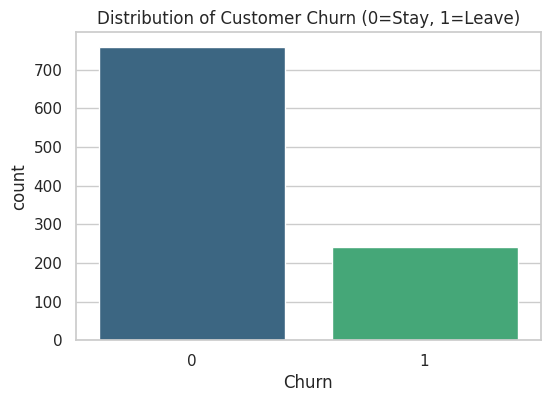

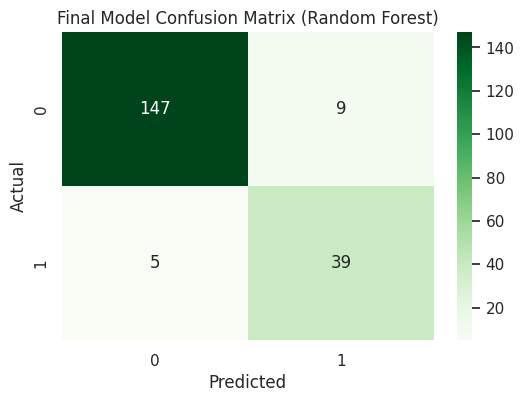

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- STEP 1: CREATE SYNTHETIC DATASET ---
np.random.seed(42)
n = 1000
data = {
    'Tenure': np.random.randint(1, 72, n),
    'MonthlyCharges': np.random.uniform(20, 120, n),
    'TotalCharges': np.random.uniform(100, 8000, n),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
    'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n),
    'Gender': np.random.choice(['Male', 'Female'], n)
}
# Logic for Churn: Month-to-month and high charges = high churn
churn_prob = ( (data['Contract'] == 'Month-to-month').astype(int) * 0.5 +
               (data['MonthlyCharges'] > 80).astype(int) * 0.3 +
               np.random.normal(0, 0.1, n) )
data['Churn'] = (churn_prob > 0.5).astype(int)

df = pd.DataFrame(data)

# --- STEP 2: EDA ---
# Plot 1: Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Customer Churn (0=Stay, 1=Leave)')
plt.savefig('churn_distribution.png')



# --- STEP 3: ENCODING & PREPROCESSING ---
le = LabelEncoder()
df['Contract'] = le.fit_transform(df['Contract'])
df['PaymentMethod'] = le.fit_transform(df['PaymentMethod'])
df['Gender'] = le.fit_transform(df['Gender'])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- STEP 4: MODEL COMPARISON ---
# Model 1: Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

# --- STEP 5: FINAL OUTPUT ---
print("--- Accuracy Comparison ---")
print(f"Logistic Regression: {acc_lr:.4f}")
print(f"Random Forest: {acc_rf:.4f}")

# Final Confusion Matrix for the best model (Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Confusion Matrix (Random Forest)')
plt.savefig('churn_confusion_matrix.png')
